<a href="https://colab.research.google.com/github/Erickpython/kodeCamp_5X-MachineLearning/blob/main/NLP_with_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task Objective

Your task is to build a Sentiment Analysis model using an LSTM (Long Short-Term Memory) network to classify movie reviews from the IMDb dataset as Positive (1) or Negative (0)

The objective is to demonstrate your understanding of Sequence modeling, Text preprocessing, Word embeddings, LSTM architecture, and Model training and evaluation.

You must implement the model yourself using PyTorch


Requirements

    Use the IMDb dataset for training and testing. Pick the first 10000 IMDb entries for your submission
    Perform appropriate text preprocessing, including:
        Tokenization
        Vocabulary creation
        Padding/truncation
        Conversion to integer sequences
    Split data into Training set and Validation set
    Use GPU if available (recommended)
    Your implementation must include:
        Proper data pipeline
        Model class definition
        Training loop
        Evaluation metrics
        Code must be well-commented and modular


Model Architecture

Your LSTM model must include:

    Embedding Layer, with embedding size between 100–300
    At least 1 or more LSTM Layers with large hidden size
    Dropout Layer to reduce overfitting
    Fully Connected (Linear) Layer with Sigmoid activation
     

Training Requirements

    Ensure to use the appropriate loss function and optimizer
    Use a batch size of 32 or 64
    Learning rate: between 0.01 to 0.001 depending on optimizer
    Epochs: 5–10 minimum
    You must:
        Track training loss
        Track validation loss
        Track validation accuracy
        Save best model (based on validation accuracy)
    Minimum Validation Accuracy: 85%
    Bonus marks for:
        ≥ 88% accuracy
        Hyperparameter tuning
        Pretrained embeddings (e.g., GloVe)


Visualization Plots

You must generate and include the following plots:

    Training vs Validation Loss
    Training vs Validation Accuracy
    Confusion Matrix


Model Evaluation

You must evaluate your final model on the test set and report:

    Test Accuracy
    Precision
    Recall
    F1 Score


Tip:
You can load IMDb from PyTorch datasets using the below code snippet:

from datasets import load_dataset



dataset = load_dataset("imdb")

train_texts = dataset["train"]["text"]



# Reduce size for faster demo

train_texts = train_texts[:10000]

## Step 1: Install and Import Libraries

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from collections import Counter
import re

In [15]:
# Set device (GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## Step 2: Data Preprocessing

We take the first 10,000 entries, tokenize them, and pad them to a fixed length.

In [16]:
# 1. Load Dataset
dataset = load_dataset("imdb")

In [17]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

## NB: Before shuffling the dataset, i got 100% accuracy which raised concerns  

Epoch    | Train Loss   | Val Loss     | Val Acc   
--------------------------------------------------
1        | 0.0170       | 0.0000       | 1.0000     <- Best model saved!
2        | 0.0000       | 0.0000       | 1.0000     
3        | 0.0000       | 0.0000       | 1.0000     
4        | 0.0000       | 0.0000       | 1.0000


## THUS I DECIDED TO SHUFFLE THE DATA

In [18]:
# Combine all train data so we can shuffle it properly
all_texts = np.array(dataset["train"]["text"])
all_labels = np.array(dataset["train"]["label"])

# Shuffle the indices
indices = np.arange(len(all_texts))
np.random.seed(42) # For reproducibility
np.random.shuffle(indices)

# Now pick the first 10,000 SHUFFLED entries
shuffled_texts = all_texts[indices[:10000]]
shuffled_labels = all_labels[indices[:10000]]

# Now proceed with your Tokenization and Vocabulary using shuffled_texts...

In [19]:
print(Counter(shuffled_labels)) # confirm is shuffled

Counter({np.int64(0): 5038, np.int64(1): 4962})


In [20]:
train_texts = shuffled_texts
train_labels = shuffled_labels

# 2. Simple Tokenizer and Vocab Creation
def clean_text(text):
    text = text.lower().replace("<br />", " ")
    return re.findall(r'\w+', text)

all_tokens = [token for text in train_texts for token in clean_text(text)]
vocab_counts = Counter(all_tokens)
# Top 10,000 words for efficiency
vocab = {word: i+2 for i, (word, _) in enumerate(vocab_counts.most_common(10000))}
vocab["<PAD>"] = 0
vocab["<UNK>"] = 1

# 3. Conversion to Sequences & Padding
def text_to_sequence(text, max_len=200):
    tokens = clean_text(text)
    seq = [vocab.get(token, 1) for token in tokens]
    if len(seq) < max_len:
        seq += [0] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
    return seq

X = np.array([text_to_sequence(t) for t in train_texts])
y = np.array(train_labels)

# 4. Split into Train (80%) and Validation (20%)
split_idx = int(0.8 * len(X))
train_x, val_x = X[:split_idx], X[split_idx:]
train_y, val_y = y[:split_idx], y[split_idx:]

train_data = DataLoader(TensorDataset(torch.LongTensor(train_x), torch.FloatTensor(train_y)), batch_size=64, shuffle=True)
val_data = DataLoader(TensorDataset(torch.LongTensor(val_x), torch.FloatTensor(val_y)), batch_size=64)

## Step 3: Model Architecture

This class defines the Embedding, LSTM, and Output layers.

In [21]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim=1):
        super(SentimentLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # Using a bidirectional LSTM
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=2,
                            batch_first=True, dropout=0.5, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim * 2, output_dim) # *2 for bidirectional
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)

        # Concatenate the final forward and backward hidden states
        out = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        out = self.dropout(out)
        out = self.fc(out)
        return self.sigmoid(out)

model = SentimentLSTM(len(vocab), embed_dim=200, hidden_dim=256).to(device)

## Step 4: Training Loop

We track loss and accuracy and save the best model weights.

In [22]:
# Training Settings
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()
epochs = 10

history = {"train_loss": [], "val_loss": [], "val_acc": []}
best_acc = 0

print(f"{'Epoch':<8} | {'Train Loss':<12} | {'Val Loss':<12} | {'Val Acc':<10}")
print("-" * 50)

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    total_train_loss = 0
    for inputs, labels in train_data:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output.squeeze(), labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    # Calculate average training loss for this epoch
    avg_train_loss = total_train_loss / len(train_data)

    # --- VALIDATION PHASE ---
    model.eval()
    total_val_loss = 0
    correct = 0

    with torch.no_grad():
        for inputs, labels in val_data:
            inputs, labels = inputs.to(device), labels.to(device)

            output = model(inputs)
            val_loss = criterion(output.squeeze(), labels)
            total_val_loss += val_loss.item()

            # Calculate accuracy
            preds = (output.squeeze() > 0.5).float()
            correct += (preds == labels).sum().item()

    avg_val_loss = total_val_loss / len(val_data)
    val_acc = correct / len(val_x)

    # Save history for the final plots
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(val_acc)

    # Save the best model weights
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pt')
        save_msg = "<- Best model saved!"
    else:
        save_msg = ""

    # Updated Print Statement
    print(f"{epoch+1:<8} | {avg_train_loss:<12.4f} | {avg_val_loss:<12.4f} | {val_acc:<10.4f} {save_msg}")

Epoch    | Train Loss   | Val Loss     | Val Acc   
--------------------------------------------------
1        | 0.6858       | 0.6910       | 0.5130     <- Best model saved!
2        | 0.6615       | 0.6136       | 0.6585     <- Best model saved!
3        | 0.5770       | 0.5492       | 0.7230     <- Best model saved!
4        | 0.4245       | 0.4695       | 0.7900     <- Best model saved!
5        | 0.3306       | 0.4422       | 0.7990     <- Best model saved!
6        | 0.2558       | 0.4977       | 0.8040     <- Best model saved!
7        | 0.1830       | 0.5299       | 0.8080     <- Best model saved!
8        | 0.1164       | 0.5881       | 0.8155     <- Best model saved!
9        | 0.0918       | 0.6399       | 0.7955     
10       | 0.0570       | 0.7128       | 0.8095     


## Step 5: Visualizations & Metrics

Finally, we generate the required plots and the Confusion Matrix.

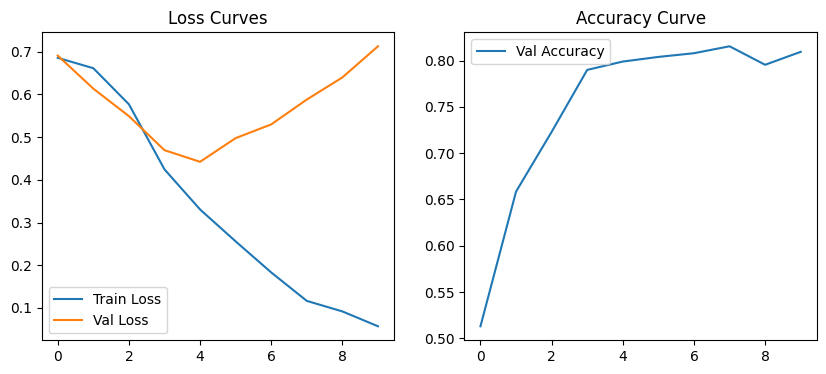

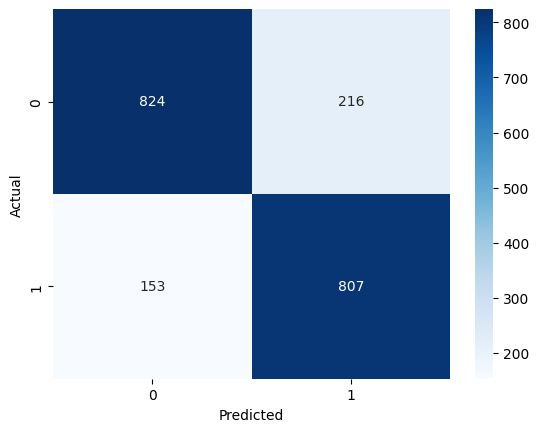

Precision: 0.7889
Recall: 0.8406
F1 Score: 0.8139


In [23]:
# Plotting Loss
plt.figure(figsize=(10,4))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Curves")

# Plotting Accuracy
plt.subplot(1, 2, 2)
plt.plot(history["val_acc"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

# Final Evaluation
model.load_state_dict(torch.load('best_model.pt'))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in val_data:
        inputs = inputs.to(device)
        output = model(inputs)
        all_preds.extend((output.squeeze() > 0.5).cpu().numpy())
        all_labels.extend(labels.numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(f"Precision: {precision_score(all_labels, all_preds):.4f}")
print(f"Recall: {recall_score(all_labels, all_preds):.4f}")
print(f"F1 Score: {f1_score(all_labels, all_preds):.4f}")